---
title: Homework Module 12
---

*Built with Grok Build*



In [2]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - HW_M12: HW8_Mark_Khusid.py
# Mark Khusid
##########################################################################################

##########################################################################################
# MW_M12
#                    
##########################################################################################


## Import Libraries


In [3]:
from pydub import AudioSegment
import numpy as np
from scipy import fftpack
import matplotlib.pyplot as plt


## Set Debug State


In [4]:
debug = True


## Load Audio Data


In [5]:
audio = AudioSegment.from_file("Audio_Mark_Khusid.m4a", format="m4a")


In [6]:
sig_clean = np.array(audio.get_array_of_samples(), dtype=float)


In [7]:
if debug:
    print(sig_clean.shape)


(164864,)


In [8]:
if debug:
    print(audio.channels)


1


## Handle Multi - Channel Data if Needed


In [9]:
if audio.channels == 2:
    sig_clean = sig_clean[::2]


## Set Sample Rate and Time Step


In [10]:
if debug:
    print(audio.frame_rate)
    print(audio.sample_width)
    print(audio.frame_width)


48000
2
2


In [11]:
sample_rate = audio.frame_rate
time_step = 1 / sample_rate


In [12]:
if debug:
    print(time_step)


2.0833333333333333e-05


## Create Time Vector


In [13]:
num_samples = sig_clean.shape[0]
time_vec = np.arange(num_samples) * time_step


## Visualize Audio File in Time Domain


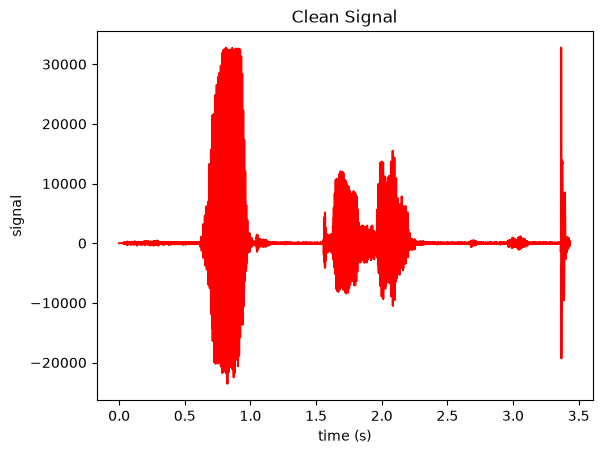

In [14]:
if debug:
    plt.plot(time_vec, sig_clean,'r')                        # plot the clean wave
    plt.xlabel('time (s)')
    plt.ylabel('signal')
    plt.title('Clean Signal')
    plt.show()


## Normalize Clean Signal


In [15]:
if debug:
    print( np.max( np.abs(sig_clean) ) )
    print( np.min( np.abs(sig_clean) ) )


32767.0
0.0


In [16]:
sig_clean_normalized = sig_clean / np.max(np.abs(sig_clean))


In [17]:
if debug:
    print(sig_clean_normalized.shape)


(164864,)


## Visualize Normalized Clean Signal


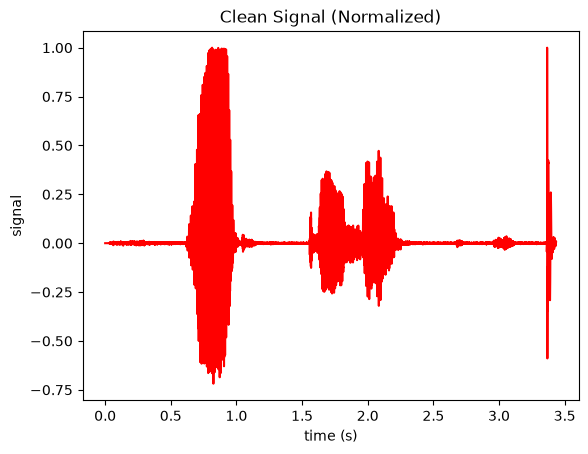

In [18]:
if debug:
    plt.plot(time_vec, sig_clean_normalized,'r')                        # plot the clean wave
    plt.xlabel('time (s)')
    plt.ylabel('signal')
    plt.title('Clean Signal (Normalized)')
    plt.show()


## Add Noise


### Set Noise Scale


In [19]:
noise_scale = 0.1


### Generate Scaled Random Numbers Vector 


In [20]:
if debug:
    print(np.random.randn(10) * noise_scale)


[-0.04524414 -0.10699796  0.08706932 -0.14697108  0.05677436  0.03071965
 -0.06960668 -0.0007997  -0.00223256 -0.08038785]


In [21]:
noise = noise_scale * np.random.randn(sig_clean.size)


## Add Noise to Clean Signal


In [22]:
sig_noisy = sig_clean_normalized + noise


## Visualize Noisy Signal


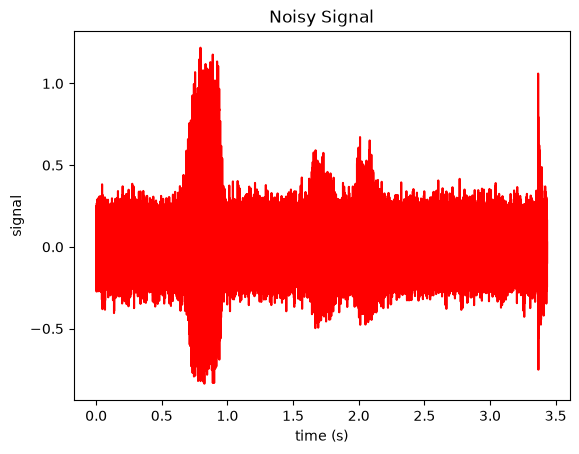

In [23]:
if debug:
    plt.plot(time_vec, sig_noisy,'r')                        # plot the clean wave
    plt.xlabel('time (s)')
    plt.ylabel('signal')
    plt.title('Noisy Signal')
    plt.show()


## Generate Fast Fourier Transform of Noisy Signal


In [24]:
sig_noisy_fft = fftpack.fft(sig_noisy)
sig_clean_fft = fftpack.fft(sig_clean_normalized)

# Common Sample Frequencies
sample_freq = fftpack.fftfreq(sig_noisy.size, d=time_step)


## Visualize FFT of Clean and Noisy Signals


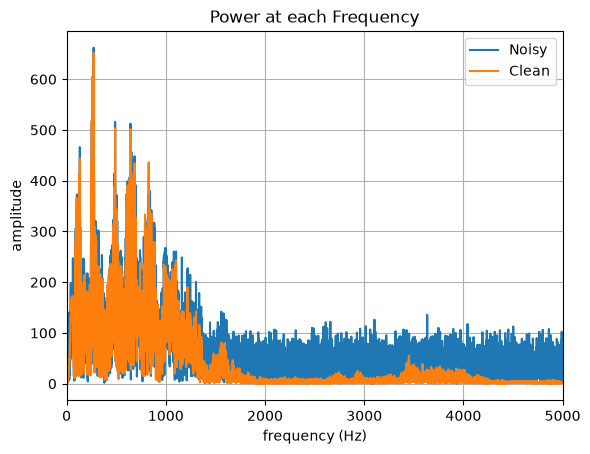

In [25]:
if debug:
    pidxs = np.nonzero(sample_freq > 0)  # pidxs is a tuple
    freqs = sample_freq[pidxs]           # this creates an array with those entries
    power_noisy = np.abs(sig_noisy_fft)[pidxs]       # compute the power of the freqs > 0
    power_clean = np.abs(sig_clean_fft)[pidxs]       # compute the power of the freqs > 0
    plt.plot(freqs, power_noisy, label="Noisy")                # and plot it
    plt.plot(freqs, power_clean, label='Clean')                # and plot it
    plt.xlabel('frequency (Hz)')
    plt.ylabel('amplitude')
    plt.title('Power at each Frequency')
    plt.xlim(0, 5000)
    plt.grid(which='both')
    plt.legend()
    plt.show()


## Filter Out the Noise


### Set Low - Pass Filter Cutoff Frequency


In [26]:
F_CO = 2000   # Hz


### Null Out Signal Power Above Filter Cutoff Frequency


In [27]:
sig_filtered_fft = sig_noisy_fft.copy()
sig_filtered_fft[np.abs(sample_freq) > F_CO] = 0


## Visualize FFT of Clean, Noisy and Filtered Signals


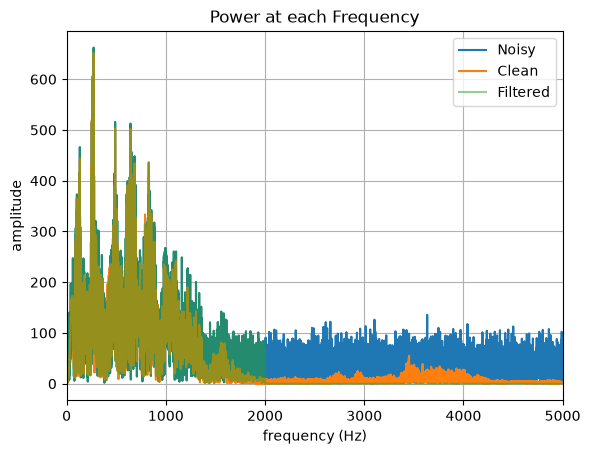

In [28]:
if debug:
    pidxs = np.nonzero(sample_freq > 0)  # pidxs is a tuple
    freqs = sample_freq[pidxs]           # this creates an array with those entries
    power_noisy = np.abs(sig_noisy_fft)[pidxs]       # compute the power of the freqs > 0
    power_clean = np.abs(sig_clean_fft)[pidxs]       # compute the power of the freqs > 0
    power_filtered = np.abs(sig_filtered_fft)[pidxs]       # compute the power of the freqs > 0
    plt.plot(freqs, power_noisy, label="Noisy")                # and plot it
    plt.plot(freqs, power_clean, label='Clean')                # and plot it
    plt.plot(freqs, power_filtered, label='Filtered', alpha=0.5)                # and plot it
    plt.xlabel('frequency (Hz)')
    plt.ylabel('amplitude')
    plt.title('Power at each Frequency')
    plt.xlim(0, 5000)
    plt.grid(which='both')
    plt.legend()
    plt.show()


## Take the Inverst Fast Fourier Transform of the Filtered Signal


In [29]:
sig_filtered_time_domain = fftpack.ifft(sig_filtered_fft).real


## Visualize Original Time Domain Signal and Recreated Time Domain Signal


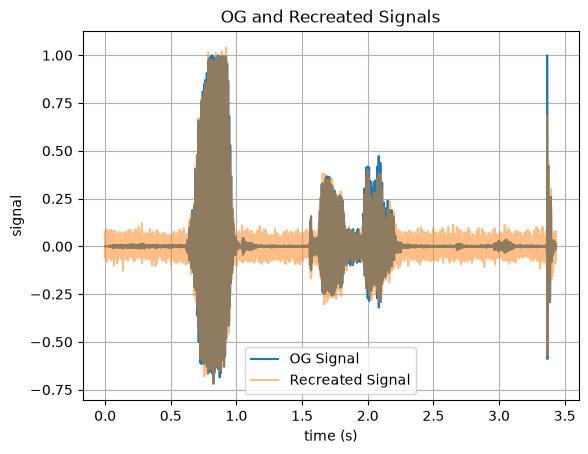

In [30]:
if debug:
    plt.plot(time_vec, sig_clean_normalized, label="OG Signal")                        # plot the clean wave
    plt.plot(time_vec, sig_filtered_time_domain, label="Recreated Signal", alpha=0.5)                        # plot the clean wave
    plt.xlabel('time (s)')
    plt.ylabel('signal')
    plt.title('OG and Recreated Signals')
    plt.legend()
    plt.grid(which='both')
    plt.show()


## Calculate and Print Mean Squared Error (MSE) for Credit


In [31]:
# MSE between clean signal and filtered noisy signal
mse_with_filtering = np.mean((sig_clean_normalized - sig_filtered_time_domain) ** 2)
mse_wo_filtering   = np.mean((sig_clean_normalized - sig_noisy               ) ** 2) # Sig_noisy is already normalized


In [32]:
print(f"Mean Squared Error (MSE) with Filtering = {mse_with_filtering:.8f}")
if debug:
    print(f"Mean Squared Error (MSE) without Filtering = {mse_wo_filtering:.8f}")


Mean Squared Error (MSE) with Filtering = 0.00091897
Mean Squared Error (MSE) without Filtering = 0.01002170
